# Website Traffic Analysis

**Dataset:** Google Analytics 4 export — hourly sessions by traffic-source channel
**Period:** April 6, 2024 – May 3, 2024
**Goal:** Understand where traffic comes from, how engaged visitors are, and when they show up, to inform business decisions.

**Contents**
1. Load & clean the data
2. Data overview
3. Traffic source analysis
4. Engagement metrics
5. Time trends (daily, hourly, day-of-week)
6. High vs. low performing channels
7. Summary dashboard
8. Key takeaways

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE = ["#2E75B6", "#ED7D31", "#70AD47", "#FFC000", "#A5A5A5", "#264478", "#9E480E"]
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Load & clean the data

The raw export has a comment line before the header, and a combined `YYYYMMDDHH` date-hour column. We split that into a proper `Date`, `Hour`, and `DayOfWeek`.

In [2]:
df = pd.read_csv('website_data.csv', skiprows=1)

df.columns = ['Channel', 'DateHour', 'Users', 'Sessions', 'EngagedSessions',
              'AvgEngTime', 'EngSessPerUser', 'EventsPerSession', 'EngagementRate', 'EventCount']

df['Date'] = pd.to_datetime(df['DateHour'].astype(str).str[:8], format='%Y%m%d')
df['Hour'] = df['DateHour'].astype(str).str[8:10].astype(int)
df['DayOfWeek'] = df['Date'].dt.day_name()
df = df.drop(columns='DateHour').sort_values(['Date', 'Hour', 'Channel']).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Missing values:\n{df.isna().sum().sum()} total")
df.head()

Shape: (3182, 12)
Date range: 2024-04-06 to 2024-05-03
Missing values:
0 total


,Channel,Users,Sessions,EngagedSessions,AvgEngTime,EngSessPerUser,EventsPerSession,EngagementRate,EventCount,Date,Hour,DayOfWeek
0,Direct,60,66,40,97.59,0.67,4.03,0.61,266,2024-04-06,0,Saturday
1,Organic Search,47,56,41,62.64,0.87,4.25,0.73,238,2024-04-06,0,Saturday
2,Organic Social,65,108,46,19.86,0.71,3.90,0.43,421,2024-04-06,0,Saturday
3,Referral,24,39,19,95.26,0.79,3.87,0.49,151,2024-04-06,0,Saturday
4,Unassigned,1,1,0,0.00,0.00,2.00,0.00,2,2024-04-06,0,Saturday


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Channel           3182 non-null   str           
 1   Users             3182 non-null   int64         
 2   Sessions          3182 non-null   int64         
 3   EngagedSessions   3182 non-null   int64         
 4   AvgEngTime        3182 non-null   float64       
 5   EngSessPerUser    3182 non-null   float64       
 6   EventsPerSession  3182 non-null   float64       
 7   EngagementRate    3182 non-null   float64       
 8   EventCount        3182 non-null   int64         
 9   Date              3182 non-null   datetime64[us]
 10  Hour              3182 non-null   int64         
 11  DayOfWeek         3182 non-null   str           
dtypes: datetime64[us](1), float64(4), int64(5), str(2)
memory usage: 298.4 KB


## 2. Data overview

Quick top-line numbers for the whole period.

In [4]:
total_users = df['Users'].sum()
total_sessions = df['Sessions'].sum()
total_engaged = df['EngagedSessions'].sum()
overall_engagement_rate = total_engaged / total_sessions
weighted_avg_time = (df['Sessions'] * df['AvgEngTime']).sum() / total_sessions
weighted_events_per_session = df['EventCount'].sum() / total_sessions
total_events = df['EventCount'].sum()

kpis = pd.Series({
    'Total Users': f"{total_users:,.0f}",
    'Total Sessions': f"{total_sessions:,.0f}",
    'Engaged Sessions': f"{total_engaged:,.0f}",
    'Engagement Rate': f"{overall_engagement_rate:.1%}",
    'Avg Engagement Time (s)': f"{weighted_avg_time:.1f}",
    'Events per Session': f"{weighted_events_per_session:.2f}",
    'Total Events': f"{total_events:,.0f}",
}, name='Value')
kpis.to_frame()

,Value
Total Users,"133,440"
Total Sessions,"162,895"
Engaged Sessions,"90,132"
Engagement Rate,55.3%
Avg Engagement Time (s),58.0
Events per Session,4.73
Total Events,"770,911"


## 3. Traffic source analysis

Which channels bring the most users and sessions, and how much of total traffic each represents.

In [5]:
channel_summary = df.groupby('Channel').agg(
    Users=('Users', 'sum'),
    Sessions=('Sessions', 'sum'),
    EngagedSessions=('EngagedSessions', 'sum'),
    EventCount=('EventCount', 'sum'),
).sort_values('Sessions', ascending=False)

channel_summary['% of Sessions'] = channel_summary['Sessions'] / channel_summary['Sessions'].sum()
channel_summary['Engagement Rate'] = channel_summary['EngagedSessions'] / channel_summary['Sessions']

# Weighted avg engagement time & events/session per channel
weighted = df.groupby('Channel').apply(
    lambda g: pd.Series({
        'Avg Engagement Time (s)': (g['Sessions'] * g['AvgEngTime']).sum() / g['Sessions'].sum(),
        'Events per Session': g['EventCount'].sum() / g['Sessions'].sum(),
    }),
    include_groups=False
)
channel_summary = channel_summary.join(weighted).sort_values('Sessions', ascending=False)
channel_summary

,Users,Sessions,EngagedSessions,EventCount,% of Sessions,Engagement Rate,Avg Engagement Time (s),Events per Session
Channel,,,,,,,,
Organic Social,47572,60627,32697,296631,0.37,0.54,52.17,4.89
Direct,30042,37203,17243,156318,0.23,0.46,46.50,4.20
Organic Search,28387,33372,19425,136957,0.20,0.58,47.24,4.10
Referral,26774,30990,20653,177992,0.19,0.67,93.69,5.74
Unassigned,540,559,4,1932,0.00,0.01,76.79,3.46
Organic Video,123,141,109,1071,0.00,0.77,180.11,7.60
Email,2,3,1,10,0.00,0.33,72.67,3.33


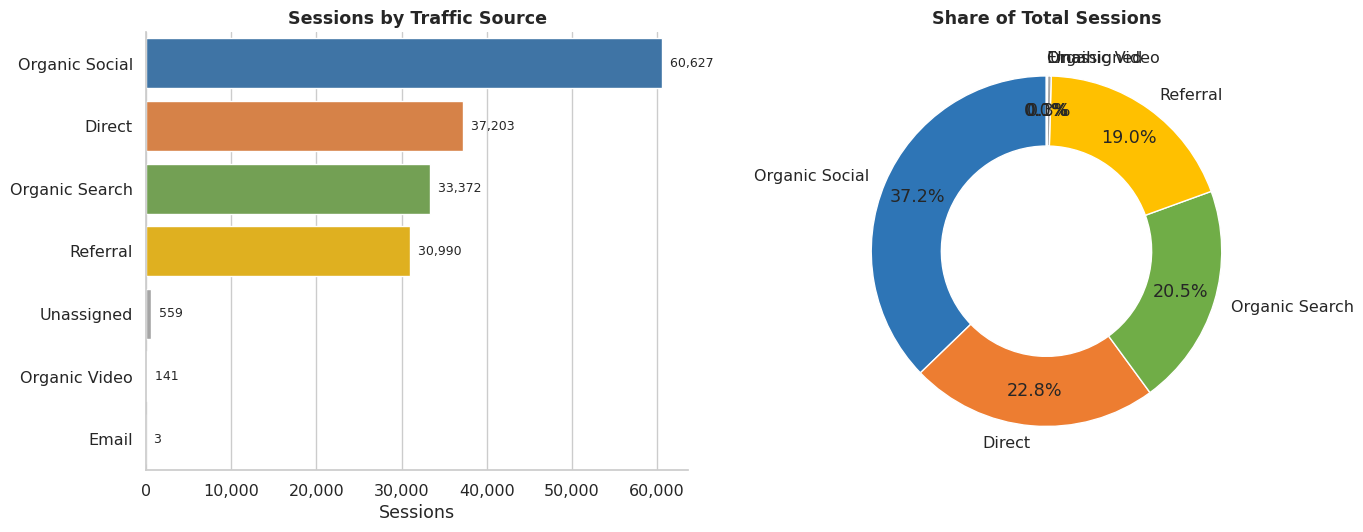

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

order = channel_summary.index
sns.barplot(x=channel_summary['Sessions'], y=order, hue=order, palette=PALETTE,
            legend=False, ax=axes[0])
axes[0].set_title('Sessions by Traffic Source', fontweight='bold')
axes[0].set_xlabel('Sessions')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, v in enumerate(channel_summary['Sessions']):
    axes[0].text(v, i, f'  {v:,.0f}', va='center', fontsize=9)

axes[1].pie(channel_summary['Sessions'], labels=order, autopct='%1.1f%%',
            colors=PALETTE, startangle=90, pctdistance=0.8,
            wedgeprops=dict(width=0.4, edgecolor='white'))
axes[1].set_title('Share of Total Sessions', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Engagement metrics

Volume alone doesn't tell the whole story — a channel that drives fewer sessions but engages visitors more deeply can be more valuable per visit.

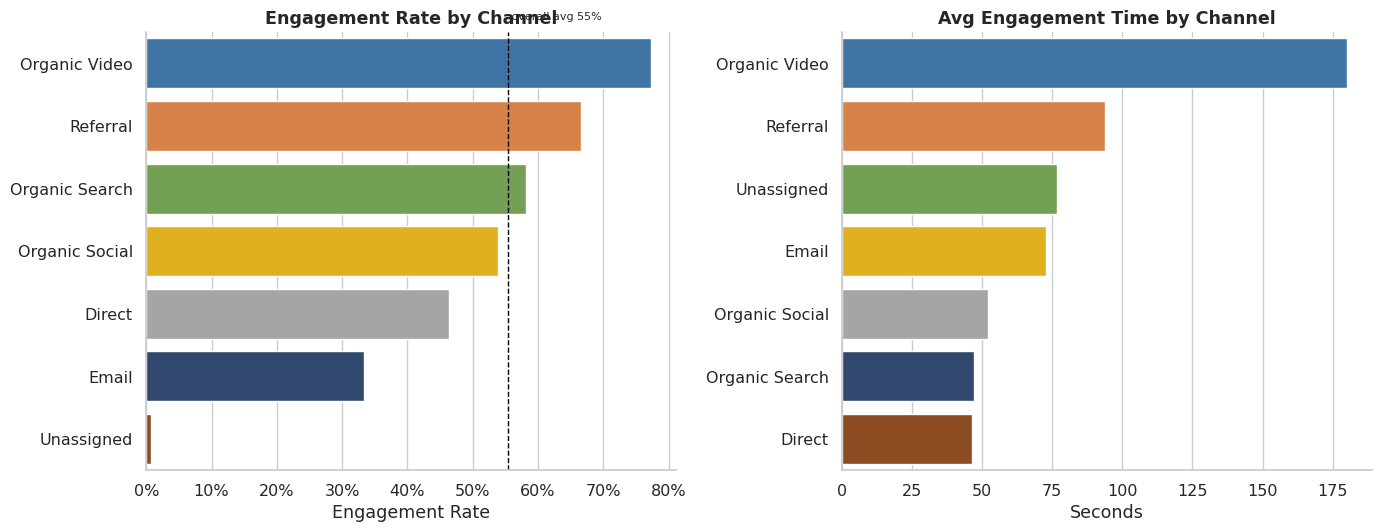

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

eng_sorted = channel_summary.sort_values('Engagement Rate', ascending=False)
sns.barplot(x=eng_sorted['Engagement Rate'], y=eng_sorted.index, hue=eng_sorted.index,
            palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title('Engagement Rate by Channel', fontweight='bold')
axes[0].set_xlabel('Engagement Rate')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].axvline(overall_engagement_rate, color='black', linestyle='--', linewidth=1)
axes[0].text(overall_engagement_rate, -0.7, f' overall avg {overall_engagement_rate:.0%}',
             fontsize=8, ha='left')

time_sorted = channel_summary.sort_values('Avg Engagement Time (s)', ascending=False)
sns.barplot(x=time_sorted['Avg Engagement Time (s)'], y=time_sorted.index, hue=time_sorted.index,
            palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title('Avg Engagement Time by Channel', fontweight='bold')
axes[1].set_xlabel('Seconds')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

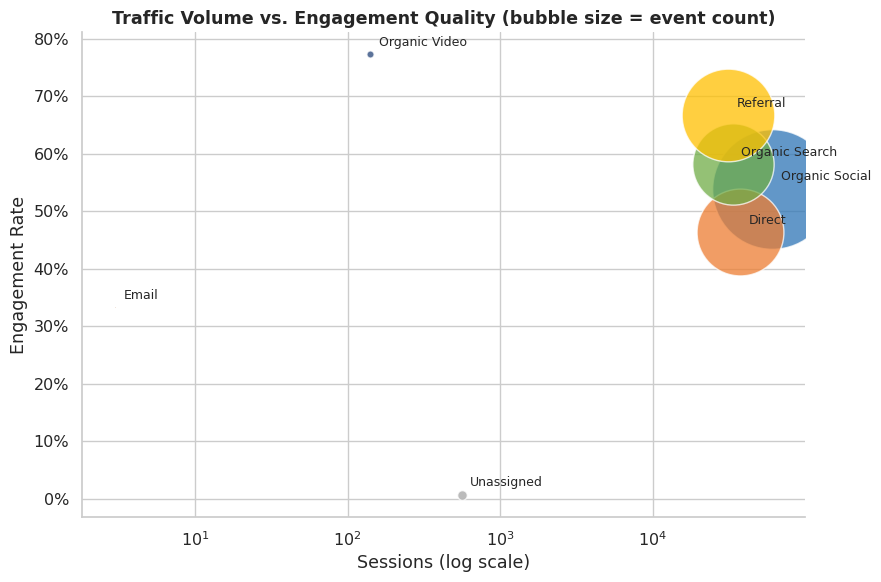

In [8]:
# Bubble chart: volume vs. engagement quality, sized by total events
fig, ax = plt.subplots(figsize=(9, 6))
for i, ch in enumerate(channel_summary.index):
    row = channel_summary.loc[ch]
    ax.scatter(row['Sessions'], row['Engagement Rate'], s=row['EventCount']/40,
               color=PALETTE[i % len(PALETTE)], alpha=0.75, edgecolor='white', linewidth=1)
    ax.annotate(ch, (row['Sessions'], row['Engagement Rate']),
                xytext=(6, 6), textcoords='offset points', fontsize=9)

ax.set_xscale('log')
ax.set_xlabel('Sessions (log scale)')
ax.set_ylabel('Engagement Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Traffic Volume vs. Engagement Quality (bubble size = event count)', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Time trends

### 5.1 Daily trend

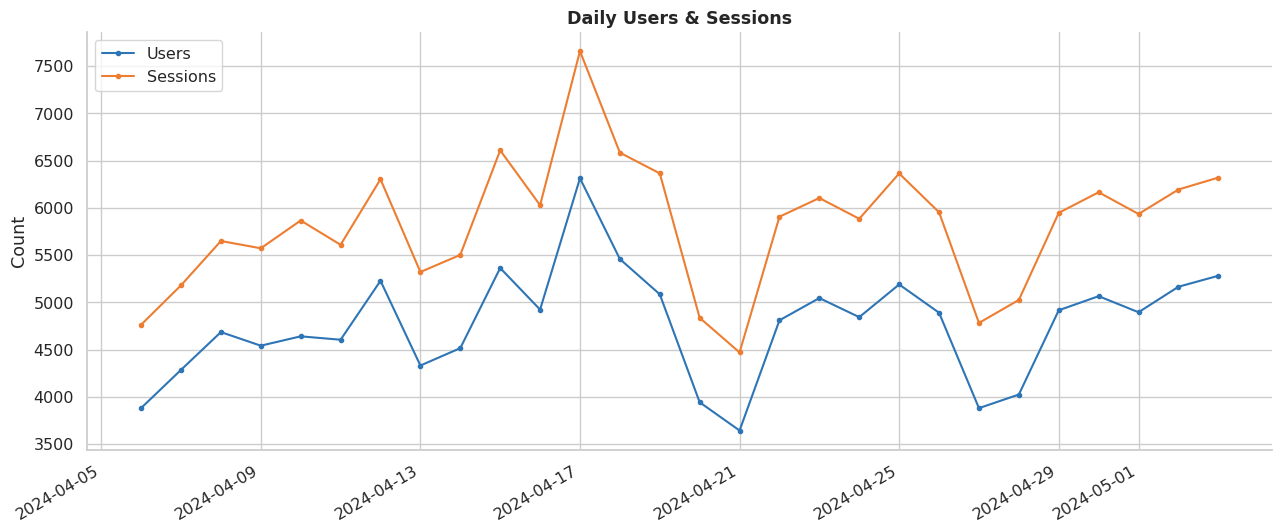

In [9]:
daily = df.groupby('Date').agg(
    Users=('Users', 'sum'),
    Sessions=('Sessions', 'sum'),
    EngagedSessions=('EngagedSessions', 'sum'),
).reset_index()
daily['Engagement Rate'] = daily['EngagedSessions'] / daily['Sessions']

fig, ax1 = plt.subplots(figsize=(13, 5.5))
ax1.plot(daily['Date'], daily['Users'], marker='o', markersize=3, color=PALETTE[0], label='Users')
ax1.plot(daily['Date'], daily['Sessions'], marker='o', markersize=3, color=PALETTE[1], label='Sessions')
ax1.set_ylabel('Count')
ax1.set_title('Daily Users & Sessions', fontweight='bold')
ax1.legend(loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 5.2 Traffic by hour of day

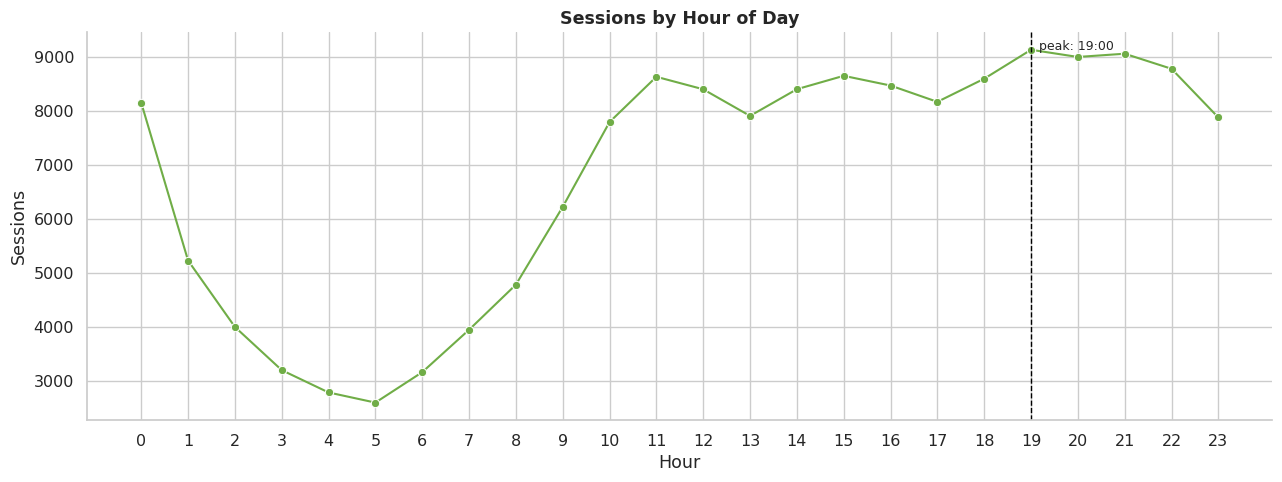

In [10]:
hourly = df.groupby('Hour').agg(
    Users=('Users', 'sum'),
    Sessions=('Sessions', 'sum'),
    EngagedSessions=('EngagedSessions', 'sum'),
).reset_index()
hourly['Engagement Rate'] = hourly['EngagedSessions'] / hourly['Sessions']

fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=hourly, x='Hour', y='Sessions', marker='o', color=PALETTE[2], ax=ax)
ax.set_title('Sessions by Hour of Day', fontweight='bold')
ax.set_xticks(range(0, 24))
peak_hour = hourly.loc[hourly['Sessions'].idxmax(), 'Hour']
ax.axvline(peak_hour, color='black', linestyle='--', linewidth=1)
ax.text(peak_hour, hourly['Sessions'].max(), f'  peak: {peak_hour}:00', fontsize=9)
plt.tight_layout()
plt.show()

### 5.3 Traffic by day of week

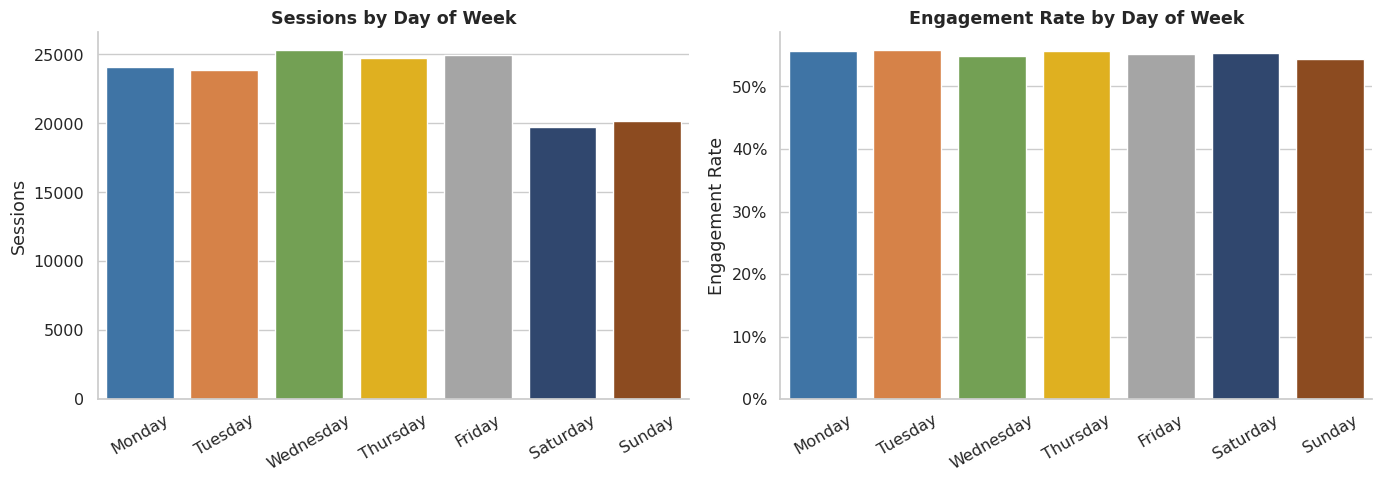

In [11]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = df.groupby('DayOfWeek').agg(
    Users=('Users', 'sum'),
    Sessions=('Sessions', 'sum'),
    EngagedSessions=('EngagedSessions', 'sum'),
).reindex(dow_order)
dow['Engagement Rate'] = dow['EngagedSessions'] / dow['Sessions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=dow.index, y=dow['Sessions'], hue=dow.index, palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title('Sessions by Day of Week', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(x=dow.index, y=dow['Engagement Rate'], hue=dow.index, palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title('Engagement Rate by Day of Week', fontweight='bold')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

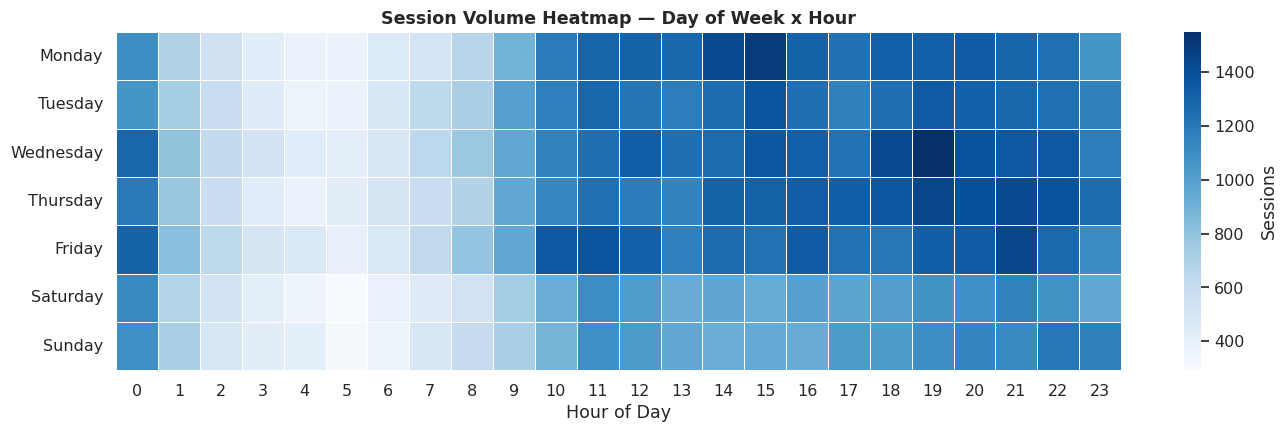

In [12]:
# Heatmap: Hour x Day-of-week session volume — spot the busiest windows
pivot = df.pivot_table(index='DayOfWeek', columns='Hour', values='Sessions', aggfunc='sum').reindex(dow_order)

fig, ax = plt.subplots(figsize=(14, 4.5))
sns.heatmap(pivot, cmap='Blues', linewidths=0.4, linecolor='white', cbar_kws={'label': 'Sessions'}, ax=ax)
ax.set_title('Session Volume Heatmap — Day of Week x Hour', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 6. High vs. low performing channels

Ranking channels on both **scale** (sessions) and **quality** (engagement rate), since the two don't always agree.

In [13]:
ranked = channel_summary.copy()
ranked['Sessions Rank'] = ranked['Sessions'].rank(ascending=False).astype(int)
ranked['Engagement Rank'] = ranked['Engagement Rate'].rank(ascending=False).astype(int)
ranked['Combined Score'] = ranked['Sessions Rank'] + ranked['Engagement Rank']
ranked = ranked.sort_values('Combined Score')

display_cols = ['Sessions', '% of Sessions', 'Engagement Rate', 'Avg Engagement Time (s)',
                 'Sessions Rank', 'Engagement Rank']
ranked[display_cols].style.format({
    'Sessions': '{:,.0f}',
    '% of Sessions': '{:.1%}',
    'Engagement Rate': '{:.1%}',
    'Avg Engagement Time (s)': '{:.1f}',
})

,Sessions,% of Sessions,Engagement Rate,Avg Engagement Time (s),Sessions Rank,Engagement Rank
Channel,,,,,,
Organic Social,"60,627",37.2%,53.9%,52.2,1,4
Organic Search,"33,372",20.5%,58.2%,47.2,3,3
Referral,"30,990",19.0%,66.6%,93.7,4,2
Direct,"37,203",22.8%,46.3%,46.5,2,5
Organic Video,141,0.1%,77.3%,180.1,6,1
Unassigned,559,0.3%,0.7%,76.8,5,7
Email,3,0.0%,33.3%,72.7,7,6


In [14]:
top_volume = channel_summary['Sessions'].idxmax()
top_quality = channel_summary['Engagement Rate'].idxmax()
low_quality = channel_summary[channel_summary['Sessions'] > channel_summary['Sessions'].median()]['Engagement Rate'].idxmin()

print(f"Highest traffic volume : {top_volume} ({channel_summary.loc[top_volume, 'Sessions']:,.0f} sessions)")
print(f"Highest engagement rate: {top_quality} ({channel_summary.loc[top_quality, 'Engagement Rate']:.1%})")
print(f"Lowest engagement among high-volume channels: {low_quality} ({channel_summary.loc[low_quality, 'Engagement Rate']:.1%})")

Highest traffic volume : Organic Social (60,627 sessions)
Highest engagement rate: Organic Video (77.3%)
Lowest engagement among high-volume channels: Direct (46.3%)


## 7. Summary dashboard

A single-page view combining the key charts for quick sharing.

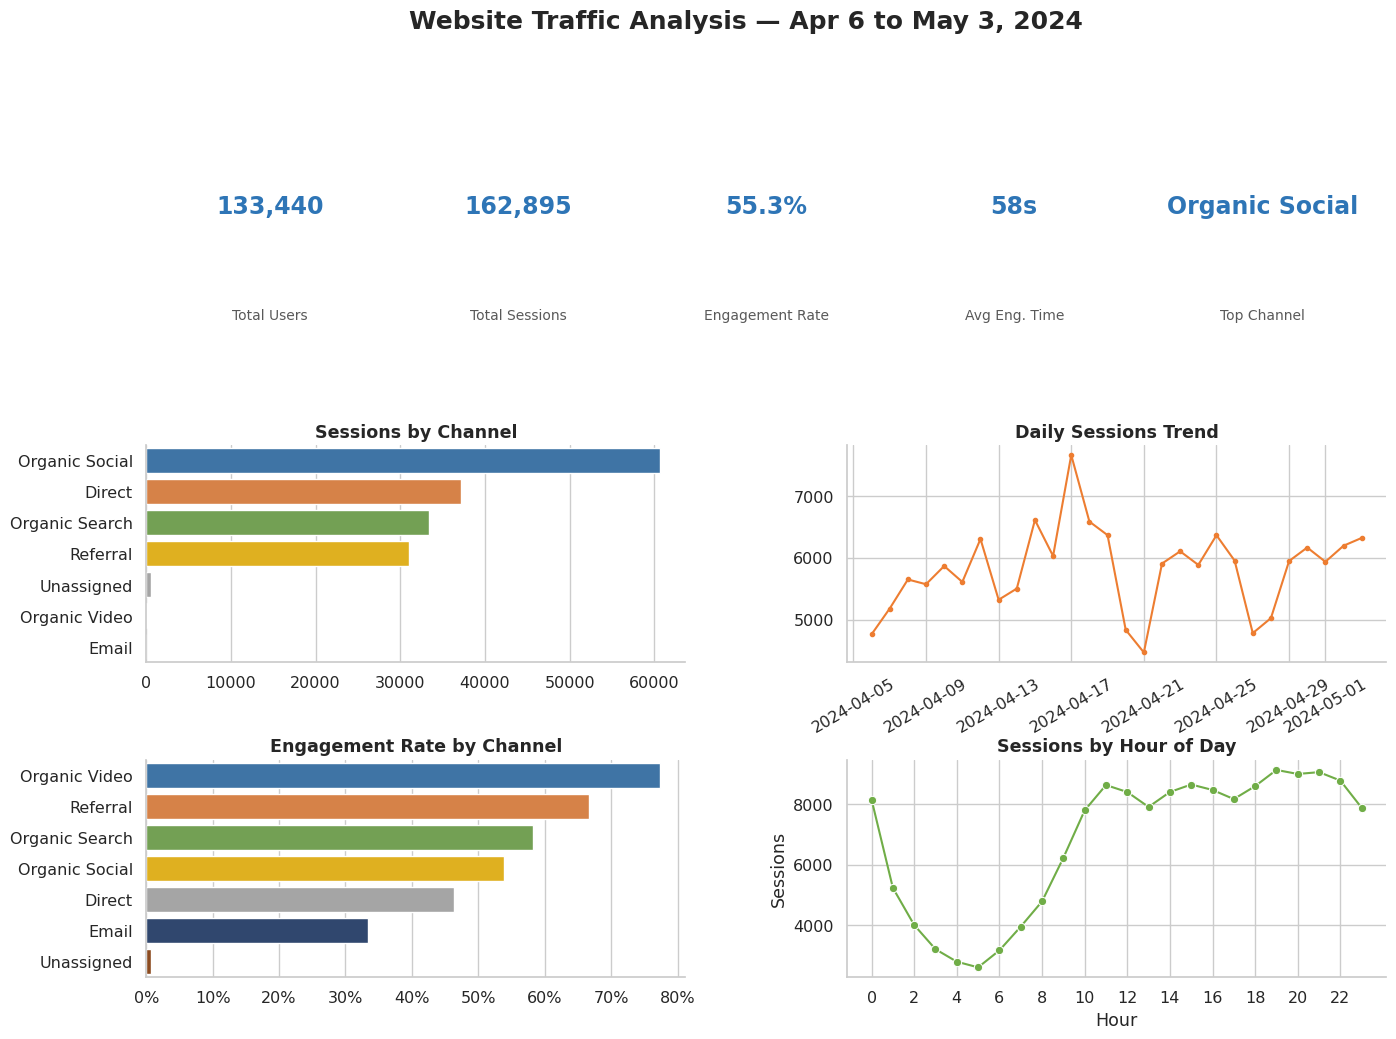

In [15]:
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.3)

fig.suptitle('Website Traffic Analysis — Apr 6 to May 3, 2024', fontsize=18, fontweight='bold', y=0.99)

# KPI strip
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')
kpi_items = [
    ('Total Users', f'{total_users:,.0f}'),
    ('Total Sessions', f'{total_sessions:,.0f}'),
    ('Engagement Rate', f'{overall_engagement_rate:.1%}'),
    ('Avg Eng. Time', f'{weighted_avg_time:.0f}s'),
    ('Top Channel', top_volume),
]
n = len(kpi_items)
for i, (label, value) in enumerate(kpi_items):
    x = (i + 0.5) / n
    ax_kpi.text(x, 0.65, value, ha='center', va='center', fontsize=17, fontweight='bold', color=PALETTE[0], transform=ax_kpi.transAxes)
    ax_kpi.text(x, 0.15, label, ha='center', va='center', fontsize=10, color='#595959', transform=ax_kpi.transAxes)

ax1 = fig.add_subplot(gs[1, 0])
sns.barplot(x=channel_summary['Sessions'], y=channel_summary.index, hue=channel_summary.index,
            palette=PALETTE, legend=False, ax=ax1)
ax1.set_title('Sessions by Channel', fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('')

ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(daily['Date'], daily['Sessions'], color=PALETTE[1], marker='o', markersize=3)
ax2.set_title('Daily Sessions Trend', fontweight='bold')
ax2.tick_params(axis='x', rotation=30)

ax3 = fig.add_subplot(gs[2, 0])
eng_sorted2 = channel_summary.sort_values('Engagement Rate', ascending=False)
sns.barplot(x=eng_sorted2['Engagement Rate'], y=eng_sorted2.index, hue=eng_sorted2.index,
            palette=PALETTE, legend=False, ax=ax3)
ax3.set_title('Engagement Rate by Channel', fontweight='bold')
ax3.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax3.set_xlabel('')
ax3.set_ylabel('')

ax4 = fig.add_subplot(gs[2, 1])
sns.lineplot(data=hourly, x='Hour', y='Sessions', marker='o', color=PALETTE[2], ax=ax4)
ax4.set_title('Sessions by Hour of Day', fontweight='bold')
ax4.set_xticks(range(0, 24, 2))

plt.show()

## 8. Key takeaways

- **Organic Social drives the most traffic** (~37% of sessions) but converts that volume into engagement at a below-average rate — worth a UX/content review to close the gap.
- **Referral traffic is the smallest of the major sources but by far the highest quality**: best engagement rate and longest average session time. These visitors likely arrive with high intent — worth investing further in the partner/referral relationships driving this.
- **Organic Video**, while very low volume, has the single highest engagement rate. If more video content could be produced or promoted, it looks like a promising growth channel.
- **Traffic is not evenly distributed across the day or week** — the heatmap highlights specific hour/day windows where sessions concentrate, which is useful for scheduling campaigns, releases, or support staffing.
- This export doesn't include page-level or conversion/goal data, so next steps would be layering in **landing page performance** and **goal completions** to connect traffic quality to business outcomes.

*This notebook recalculates automatically if `website_data.csv` is replaced with a newer export — just re-run all cells.*